# Fast-Track ML & AI - Google Colab Notebook consolidated cells: Python, SQL, NumPy/Pandas, visualization, scikit-learn, deep learning (GPU), NLP, and a TobaSkor capstone.**Before running:** Runtime > Change runtime type > Hardware accelerator > **GPU** > Save. Then run cells top to bottom.

In [1]:
# Cell 1 {Setup & GPU} - Confirm GPU, verify TF/Torch see it, install extras, core imports
!nvidia-smi
!pip install -q pandasql streamlit transformers pyngrok 2>/dev/null

import tensorflow as tf, torch
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme()

print("TF:", tf.__version__, "| GPUs:", tf.config.list_physical_devices('GPU'))
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("numpy", np.__version__, "| pandas", pd.__version__)
# If GPU list is empty: Runtime > Change runtime type > GPU > Save, then re-run.

Sun May 17 23:33:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Cell 2 {Python Basics} - Types, collections, control flow, functions, comprehensions
x, y, name, done = 10, 3.14, "Samuel", True
print(type(x), type(y), type(name), type(done))

msg = "machine learning"
print(msg.upper(), msg.split())

nums = [1, 2, 3, 4, 5]; nums.append(6)
print(nums[0], nums[-1], nums[1:4])                 # index + slice
print((35.7148, 139.7967))                          # tuple = immutable

student = {"name": "Ani", "score": 87}
student["grade"] = "A"
print(student, student.get("missing", "N/A"))
print({"ml", "ai", "ml", "python"})                 # set drops dupes

for i in range(5):
    print(i, "even" if i % 2 == 0 else "odd")

def predict_grade(score, threshold=70):
    return "PASS" if score >= threshold else "FAIL"
print(predict_grade(85), predict_grade(60, threshold=50))

print([v**2 for v in range(10)])                    # comprehension
print([v for v in range(20) if v % 2 == 0])

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>
MACHINE LEARNING ['machine', 'learning']
1 6 [2, 3, 4]
(35.7148, 139.7967)
{'name': 'Ani', 'score': 87, 'grade': 'A'} N/A
{'python', 'ai', 'ml'}
0 even
1 odd
2 even
3 odd
4 even
PASS PASS
[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [3]:
# Cell 3 {Python OOP & Errors} - Classes and exception handling
class Farmer:
    def __init__(self, name, hectares):
        self.name, self.hectares = name, hectares
    def yearly_yield(self, per_hectare):
        return self.hectares * per_hectare

f = Farmer("Pak Budi", 2.5)
print(f.name, "->", f.yearly_yield(per_hectare=4500), "kg/year")

def safe_div(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        return None
print(safe_div(10, 2), safe_div(10, 0))

Pak Budi -> 11250.0 kg/year
5.0 None


In [4]:
# Cell 4 {SQL Part 1} - Create in-memory DB, insert rows, SELECT / WHERE / ORDER / GROUP BY
import sqlite3
conn = sqlite3.connect(":memory:")
cur = conn.cursor()

cur.execute("""CREATE TABLE farmers (
  id INTEGER PRIMARY KEY, name TEXT NOT NULL,
  village TEXT, hectares REAL, monthly_income INTEGER)""")
cur.executemany(
    "INSERT INTO farmers (name,village,hectares,monthly_income) VALUES (?,?,?,?)",
    [("Pak Budi","Balige",2.5,3500000), ("Ibu Maria","Porsea",1.8,2800000),
     ("Pak Tigor","Laguboti",4.0,5200000), ("Ibu Rina","Balige",1.2,2100000)])
conn.commit()

print("-- top 2 by income, hectares > 1.5 --")
for r in cur.execute("""SELECT name, monthly_income FROM farmers
    WHERE hectares > 1.5 ORDER BY monthly_income DESC LIMIT 2"""):
    print(r)

print("-- aggregates by village --")
for r in cur.execute("""SELECT village, COUNT(*), AVG(monthly_income), SUM(hectares)
    FROM farmers GROUP BY village"""):
    print(r)

-- top 2 by income, hectares > 1.5 --
('Pak Tigor', 5200000)
('Pak Budi', 3500000)
-- aggregates by village --
('Balige', 2, 2800000.0, 3.7)
('Laguboti', 1, 5200000.0, 4.0)
('Porsea', 1, 2800000.0, 1.8)


In [5]:
# Cell 5 {SQL Part 2} - JOIN, read into pandas, query a DataFrame with SQL
cur.execute("CREATE TABLE harvests (farmer_id INTEGER, crop TEXT, yield_kg INTEGER)")
cur.executemany("INSERT INTO harvests VALUES (?,?,?)",
    [(1,"rice",8500),(2,"corn",6200),(3,"rice",14000),(1,"corn",5400)])
conn.commit()

print("-- JOIN farmers + harvests --")
for r in cur.execute("""SELECT f.name, h.crop, h.yield_kg
    FROM farmers f INNER JOIN harvests h ON f.id = h.farmer_id
    ORDER BY h.yield_kg DESC"""):
    print(r)

df_farmers = pd.read_sql("SELECT * FROM farmers", conn)
conn.close()
print(df_farmers)

from pandasql import sqldf  # run SQL directly against a DataFrame
print(sqldf("SELECT village, AVG(monthly_income) AS avg_inc "
            "FROM df_farmers GROUP BY village", {"df_farmers": df_farmers}))

-- JOIN farmers + harvests --
('Pak Tigor', 'rice', 14000)
('Pak Budi', 'rice', 8500)
('Ibu Maria', 'corn', 6200)
('Pak Budi', 'corn', 5400)
   id       name   village  hectares  monthly_income
0   1   Pak Budi    Balige       2.5         3500000
1   2  Ibu Maria    Porsea       1.8         2800000
2   3  Pak Tigor  Laguboti       4.0         5200000
3   4   Ibu Rina    Balige       1.2         2100000
    village    avg_inc
0    Balige  2800000.0
1  Laguboti  5200000.0
2    Porsea  2800000.0


In [6]:
# Cell 6 {NumPy} - Arrays, vectorized math, slicing, broadcasting
a = np.array([1, 2, 3, 4, 5])
print("a*2 =", a * 2, "| mean", a.mean(), "| std", round(a.std(), 3))
print(np.arange(0, 10, 2), np.linspace(0, 1, 5))

m = np.arange(12).reshape(3, 4)
print(m)
print("col1:", m[:, 1], "| row1:", m[1, :])
print("broadcast:\n", m + np.array([10, 20, 30, 40]))

a*2 = [ 2  4  6  8 10] | mean 3.0 | std 1.414
[0 2 4 6 8] [0.   0.25 0.5  0.75 1.  ]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
col1: [1 5 9] | row1: [4 5 6 7]
broadcast:
 [[10 21 32 43]
 [14 25 36 47]
 [18 29 40 51]]


Now we continue with the popular  Titanic dataset

In [7]:
# Cell 7 {Pandas Load & Inspect} - Read Titanic from URL, inspect structure
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)
print("shape:", titanic.shape)
titanic.info()
titanic.head()

shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Cell 8 {Pandas Clean & Engineer} - Filter, handle nulls, groupby, new features
print(titanic[(titanic["Sex"]=="female") & (titanic["Pclass"]==1)].shape,
      "first-class women")

titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic = titanic.dropna(subset=["Embarked"]).drop(columns=["Cabin"])
print("missing left:", titanic.isnull().sum().sum())

print(titanic.groupby(["Pclass", "Sex"])["Survived"].mean())

titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)
titanic["Title"] = titanic["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
titanic[["Name", "Title", "FamilySize", "IsAlone"]].head()

(94, 12) first-class women
missing left: 0
Pclass  Sex   
1       female    0.967391
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64


,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


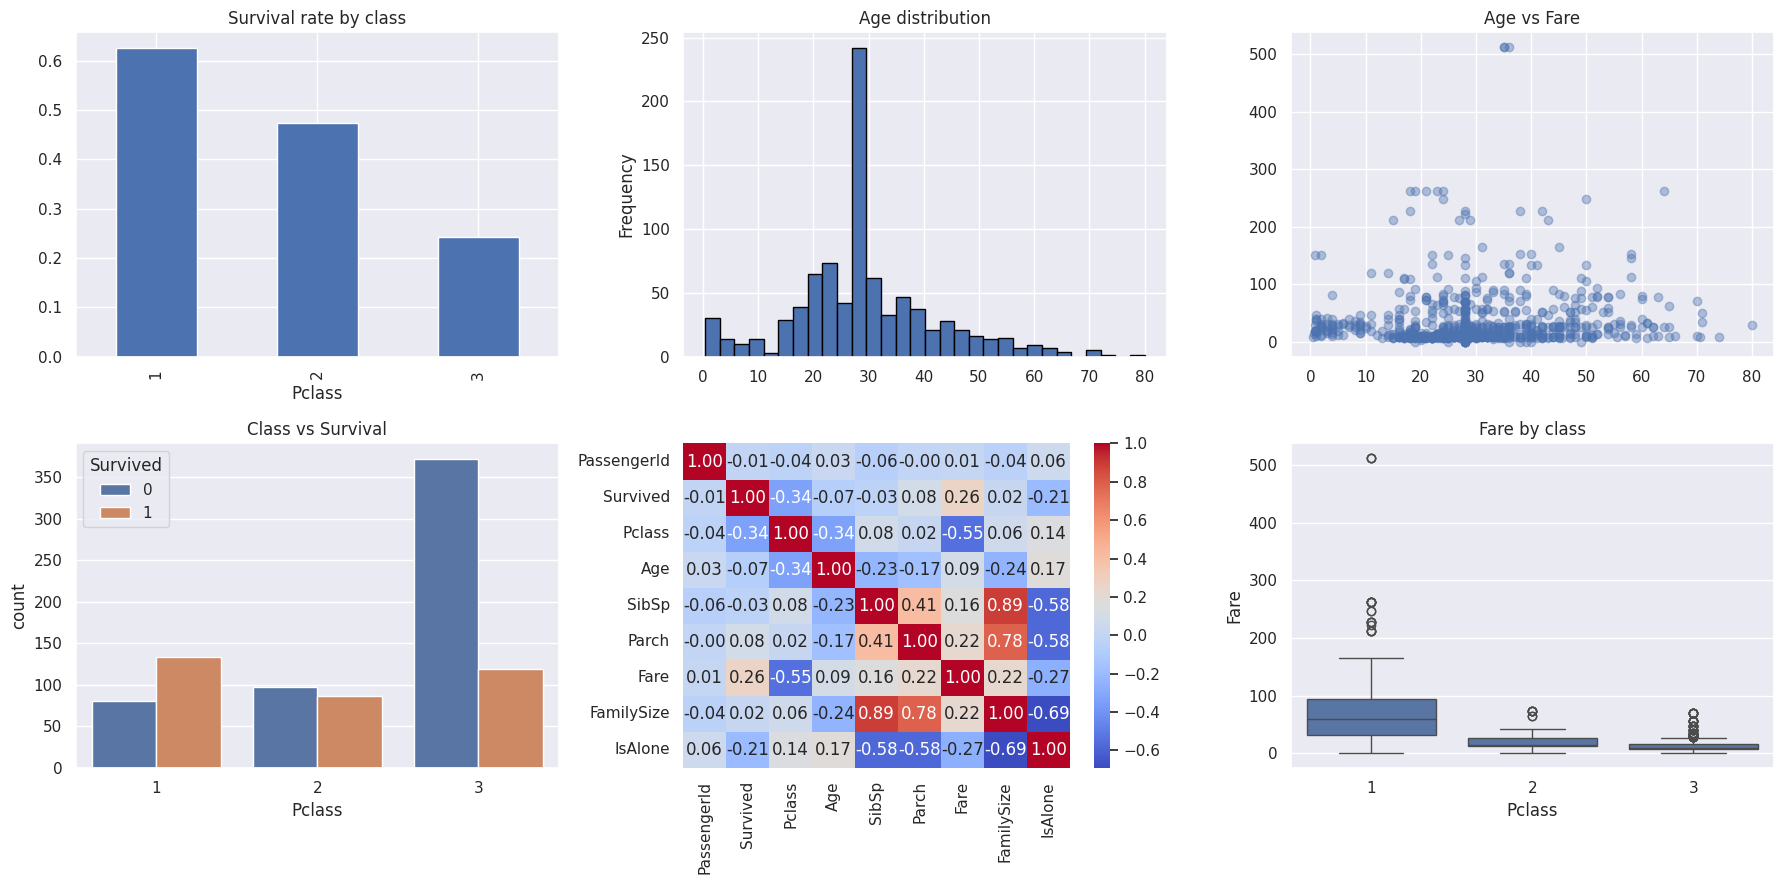

In [9]:
# Cell 9 {Visualization} - Bar, histogram, scatter, countplot, heatmap, boxplot
fig, ax = plt.subplots(2, 3, figsize=(18, 9))

titanic.groupby("Pclass")["Survived"].mean().plot(kind="bar", ax=ax[0,0],
    title="Survival rate by class")
titanic["Age"].plot(kind="hist", bins=30, edgecolor="black", ax=ax[0,1],
    title="Age distribution")
ax[0,2].scatter(titanic["Age"], titanic["Fare"], alpha=0.4)
ax[0,2].set_title("Age vs Fare")
sns.countplot(data=titanic, x="Pclass", hue="Survived", ax=ax[1,0])
ax[1,0].set_title("Class vs Survival")
sns.heatmap(titanic.select_dtypes(include="number").corr(),
    annot=True, cmap="coolwarm", fmt=".2f", ax=ax[1,1])
sns.boxplot(data=titanic, x="Pclass", y="Fare", ax=ax[1,2])
ax[1,2].set_title("Fare by class")
plt.tight_layout(); plt.show()

In [10]:
# Cell 10 {ML Prep} - Encode, train/test split, feature scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

t = titanic.copy()
t["Sex"] = (t["Sex"] == "female").astype(int)
X = t[["Pclass", "Sex", "Age", "Fare", "FamilySize", "IsAlone"]]
y = t["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_s  = scaler.transform(X_test)        # same transform on test
print("train:", X_train.shape, "| test:", X_test.shape)

train: (711, 6) | test: (178, 6)


In [11]:
# Cell 11 {ML Classifiers} - Train 7 algorithms, compare accuracy in one table
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

results = {}
# scaled-data models
for nm, mdl in [("LogReg", LogisticRegression(max_iter=1000)),
                ("KNN", KNeighborsClassifier(n_neighbors=5)),
                ("SVM", SVC(kernel="rbf"))]:
    mdl.fit(X_train_s, y_train)
    results[nm] = mdl.score(X_test_s, y_test)
# tree/raw-data models (no scaling needed)
for nm, mdl in [("DecisionTree", DecisionTreeClassifier(max_depth=4, random_state=42)),
                ("RandomForest", RandomForestClassifier(n_estimators=300,
                    max_depth=8, random_state=42, n_jobs=-1)),
                ("GradBoost", GradientBoostingClassifier(n_estimators=200,
                    max_depth=3, learning_rate=0.05, random_state=42)),
                ("NaiveBayes", GaussianNB())]:
    mdl.fit(X_train, y_train)
    results[nm] = mdl.score(X_test, y_test)

print(pd.Series(results).sort_values(ascending=False).round(4))

RandomForest    0.8202
GradBoost       0.8146
KNN             0.8090
SVM             0.8090
LogReg          0.8034
DecisionTree    0.7921
NaiveBayes      0.7865
dtype: float64


LinReg  MSE: 0.5559 | R^2: 0.5758


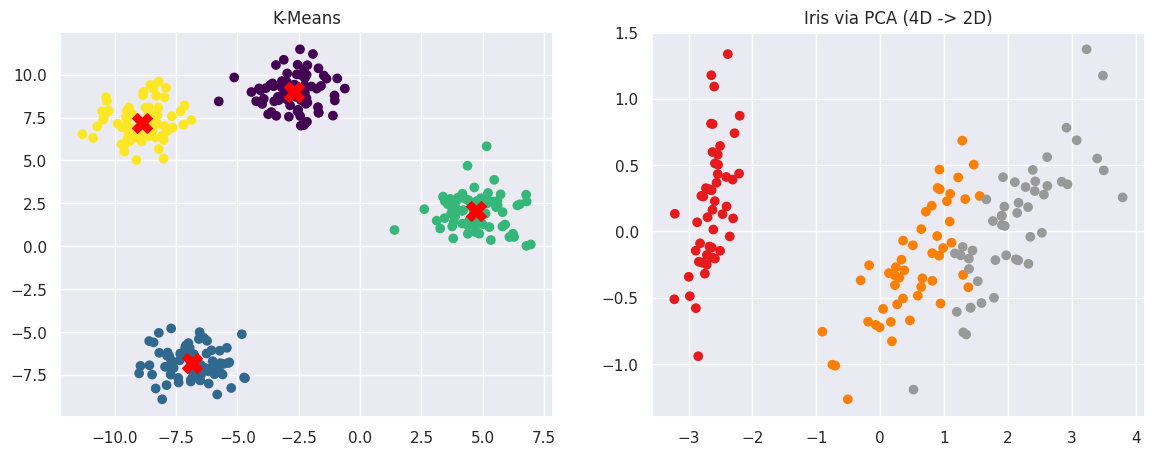

In [12]:
# Cell 12 {ML Regression & Unsupervised} - Linear Regression, K-Means, PCA
from sklearn.datasets import fetch_california_housing, load_iris, make_blobs
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

ca = fetch_california_housing(as_frame=True)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(ca.data, ca.target,
                                              test_size=0.2, random_state=42)
lr = LinearRegression().fit(Xr_tr, yr_tr)
pr = lr.predict(Xr_te)
print("LinReg  MSE:", round(mean_squared_error(yr_te, pr), 4),
      "| R^2:", round(r2_score(yr_te, pr), 4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
Xb, _ = make_blobs(n_samples=300, centers=4, random_state=42)
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xb)
ax[0].scatter(Xb[:,0], Xb[:,1], c=km.labels_, cmap="viridis")
ax[0].scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
              c="red", marker="X", s=200); ax[0].set_title("K-Means")

iris = load_iris()
proj = PCA(n_components=2).fit_transform(iris.data)
ax[1].scatter(proj[:,0], proj[:,1], c=iris.target, cmap="Set1")
ax[1].set_title("Iris via PCA (4D -> 2D)")
plt.show()

5-fold CV: [0.803 0.831 0.86  0.831 0.864] | mean 0.838
best params: {'max_depth': None, 'n_estimators': 300} | test: 0.7865
[[92 18]
 [20 48]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        68

    accuracy                           0.79       178
   macro avg       0.77      0.77      0.77       178
weighted avg       0.79      0.79      0.79       178



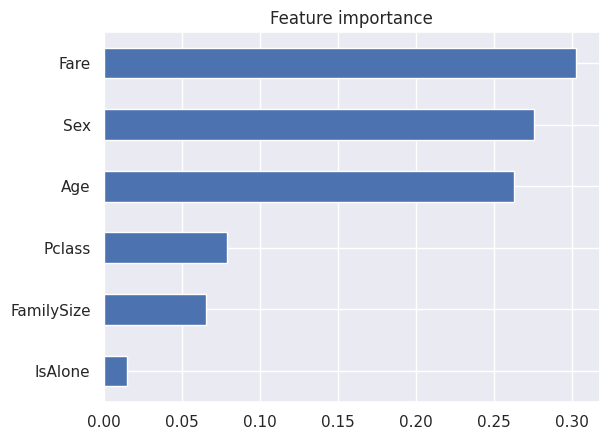

In [13]:
# Cell 13 {ML Tuning} - Cross-validation, GridSearchCV, confusion matrix, feature importance
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

rf = RandomForestClassifier(n_estimators=300, max_depth=8,
                            random_state=42, n_jobs=-1).fit(X_train, y_train)
cv = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print("5-fold CV:", cv.round(3), "| mean", round(cv.mean(), 4))

gs = GridSearchCV(RandomForestClassifier(random_state=42),
    {"n_estimators":[100,300], "max_depth":[4,8,None]},
    cv=3, scoring="accuracy", n_jobs=-1).fit(X_train, y_train)
print("best params:", gs.best_params_, "| test:", round(gs.score(X_test, y_test), 4))

pred = gs.best_estimator_.predict(X_test)
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
pd.Series(gs.best_estimator_.feature_importances_,
          index=X.columns).sort_values().plot(kind="barh",
          title="Feature importance"); plt.show()

In [14]:
# Cell 14 {ML Pipeline & Persistence} - Pipeline (no leakage), save + reload model
from sklearn.pipeline import Pipeline
import joblib

pipe = Pipeline([("scaler", StandardScaler()),
                 ("clf", LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)
print("pipeline accuracy:", round(pipe.score(X_test, y_test), 4))

joblib.dump(pipe, "titanic_logreg.joblib")
print("reloaded predicts:", joblib.load("titanic_logreg.joblib").predict(X_test.head()))

pipeline accuracy: 0.8034
reloaded predicts: [0 0 0 0 0]


Keras device: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Test accuracy: 0.8427


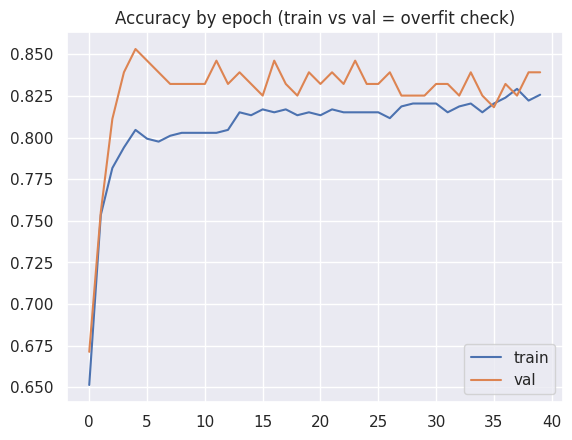

In [15]:
# Cell 15 {Deep Learning: Tabular} - First neural net on Titanic, GPU, overfitting curve
from tensorflow.keras import layers, models
print("Keras device:", tf.config.list_physical_devices('GPU'))  # auto-uses GPU

nn = models.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")])
nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist = nn.fit(X_train_s, y_train, validation_split=0.2,
              epochs=40, batch_size=32, verbose=0)
print("Test accuracy:", round(nn.evaluate(X_test_s, y_test, verbose=0)[1], 4))

plt.plot(hist.history["accuracy"], label="train")
plt.plot(hist.history["val_accuracy"], label="val")
plt.legend(); plt.title("Accuracy by epoch (train vs val = overfit check)")
plt.show()

In [16]:
# Cell 16 {Deep Learning: Images} - MNIST dense net + CNN on the GPU
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.mnist.load_data()
x_tr, x_te = x_tr/255.0, x_te/255.0          # normalize pixels to 0-1

mlp = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")])
mlp.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
mlp.fit(x_tr, y_tr, epochs=5, validation_split=0.1, batch_size=128, verbose=0)
print("Dense MNIST test acc:", round(mlp.evaluate(x_te, y_te, verbose=0)[1], 4))

cnn = models.Sequential([
    layers.Conv2D(32, 3, activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")])
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.fit(x_tr.reshape(-1,28,28,1), y_tr, epochs=3,
        validation_split=0.1, batch_size=128, verbose=0)
print("CNN MNIST test acc:",
      round(cnn.evaluate(x_te.reshape(-1,28,28,1), y_te, verbose=0)[1], 4))
cnn.save("mnist_cnn.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Dense MNIST test acc: 0.973


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN MNIST test acc: 0.9871


In [17]:
# Cell 17 {NLP} - Hugging Face on GPU (sentiment + zero-shot) and a TF-IDF baseline
# Do this in real situation; but for now here it's only example
from transformers import pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

sentiment = pipeline("sentiment-analysis", device=0)   # device=0 = GPU
print(sentiment("TobaConnect got my farm a fair price for the first time"))
print(sentiment("The app crashed three times today"))

zs = pipeline("zero-shot-classification", device=0)
out = zs("Pak Budi reported a poor rice harvest due to drought",
         candidate_labels=["weather", "pest", "market price", "logistics"])
print(list(zip(out["labels"], np.round(out["scores"], 3))))

docs = ["fair price great app","app crashed terrible","good harvest happy",
        "late payment bad service","love this platform","broken and slow"]
lab = [1,0,1,0,1,0]
vec = TfidfVectorizer(); Xt = vec.fit_transform(docs)
tclf = LogisticRegression().fit(Xt, lab)
print(tclf.predict(vec.transform(["fast and fair", "slow broken app"])))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9970869421958923}]


No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


[{'label': 'NEGATIVE', 'score': 0.9995912909507751}]


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[('weather', np.float64(0.597)), ('market price', np.float64(0.212)), ('logistics', np.float64(0.13)), ('pest', np.float64(0.06))]
[0 0]


Now we continue with the Toba Farmet Credit Data

In [18]:
# Cell 18 {Capstone: Data} - Build synthetic TobaSkor farmer-credit dataset
# Create a random dummy data for experiment or simulation
rng = np.random.default_rng(42)
N = 1000
credit = pd.DataFrame({
    "hectares": rng.uniform(0.5, 6.0, N).round(2),
    "years_farming": rng.integers(1, 35, N),
    "monthly_income": rng.integers(1_500_000, 12_000_000, N),
    "past_loans_repaid": rng.integers(0, 8, N),
    "village_distance_km": rng.uniform(1, 80, N).round(1)})
logit = (-2 + 0.3*credit["hectares"] + 0.05*credit["years_farming"]
         + credit["monthly_income"]/4_000_000
         + 0.4*credit["past_loans_repaid"]
         - 0.02*credit["village_distance_km"])
credit["will_repay"] = (rng.random(N) < 1/(1+np.exp(-logit))).astype(int)
print(credit["will_repay"].value_counts())
credit.head()

will_repay
1    835
0    165
Name: count, dtype: int64


,hectares,years_farming,monthly_income,past_loans_repaid,village_distance_km,will_repay
0,4.76,30,9669366,2,3.7,1
1,2.91,3,8554468,6,55.0,1
2,5.22,14,11264294,0,76.1,1
3,4.34,16,11586163,3,66.5,1
4,1.02,28,8901509,6,22.9,1


best params: {'max_depth': 5, 'n_estimators': 400}
ROC AUC: 0.8782
              precision    recall  f1-score   support

           0       1.00      0.21      0.35        33
           1       0.87      1.00      0.93       167

    accuracy                           0.87       200
   macro avg       0.93      0.61      0.64       200
weighted avg       0.89      0.87      0.83       200



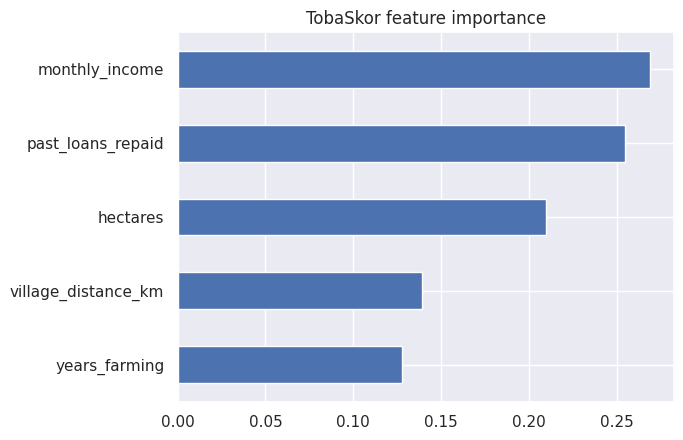

['tobaskor_model.joblib']

In [19]:
# Cell 19 {Capstone: Model} - Train tuned RF scorer, evaluate with ROC AUC, save
from sklearn.metrics import roc_auc_score

Xc = credit.drop(columns=["will_repay"]); yc = credit["will_repay"]
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)

credit_gs = GridSearchCV(RandomForestClassifier(random_state=42),
    {"n_estimators":[200,400], "max_depth":[5,10,None]},
    cv=3, scoring="roc_auc", n_jobs=-1).fit(Xc_tr, yc_tr)
credit_model = credit_gs.best_estimator_

proba = credit_model.predict_proba(Xc_te)[:, 1]
print("best params:", credit_gs.best_params_)
print("ROC AUC:", round(roc_auc_score(yc_te, proba), 4))
print(classification_report(yc_te, credit_model.predict(Xc_te)))
pd.Series(credit_model.feature_importances_,
          index=Xc.columns).sort_values().plot(kind="barh",
          title="TobaSkor feature importance"); plt.show()
joblib.dump(credit_model, "tobaskor_model.joblib")

In [20]:
# Cell 20 {Capstone: Score} - Score a single applicant and make a decision
applicant = pd.DataFrame([{
    "hectares": 3.2, "years_farming": 12, "monthly_income": 4_800_000,
    "past_loans_repaid": 3, "village_distance_km": 15.0}])
p = credit_model.predict_proba(applicant)[0][1]
print(f"Repayment probability: {p*100:.1f}%")
print("Decision:", "APPROVE" if p > 0.5 else "REVIEW")

Repayment probability: 78.2%
Decision: APPROVE


In [21]:
# Cell 21 {Deploy} - Write Streamlit app and expose it from Colab via ngrok

In [22]:
# Cell 22 {Save & Roadmap} - Persist models to Drive + post-bootcamp plan
# Do this in real situation; but for now here it's only example
# from google.colab import drive
# import os, shutil
# drive.mount('/content/drive')
# os.makedirs('/content/drive/MyDrive/ml-bootcamp', exist_ok=True)
#for fn in ["titanic_logreg.joblib","mnist_cnn.keras","tobaskor_model.joblib"]:
#    if os.path.exists(fn):
#        shutil.copy(fn, f"/content/drive/MyDrive/ml-bootcamp/{fn}")
#        print("saved", fn)

Good luck!